In [1]:
!pip install python-barcode[images]
!pip install qrcode
!apt install libzbar0
!pip install pyzbar


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.0/213.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.7 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript gsfonts imagemagick-6-common
  libdjvulibre-text libdjvulibre21 libfftw3-double3 libgs9 libgs9-common libidn12 libijs-0.35
  libjbig2dec0 libjxr-tools libjxr0 liblqr-1-0 libmagickcore-6.q16-6 libmagickcore-6.q16-6-extra
  libmagickwand-6.q16-6 libv4l-0 libv4lconvert0 libwmflite-0.2-7 poppler-data
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre ghostscript-x libfftw3-bin
  libfftw3-dev inkscape poppler-utils fonts-japanese-mincho | fonts-ipafont-mincho
  fonts-japanese-gothic | fonts-ipafont-gothic fonts-arphic-ukai fonts-arphic-uming fonts-nanum
The following NEW packages will b

In [9]:

import cv2
import numpy as np
from matplotlib import pyplot as plt
from barcode import EAN13
from barcode.writer import ImageWriter
import qrcode
from PIL import Image
from pyzbar.pyzbar import decode
%matplotlib inline

In [4]:
def imshow(title,image):
    plt.figure(figsize=(10,8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

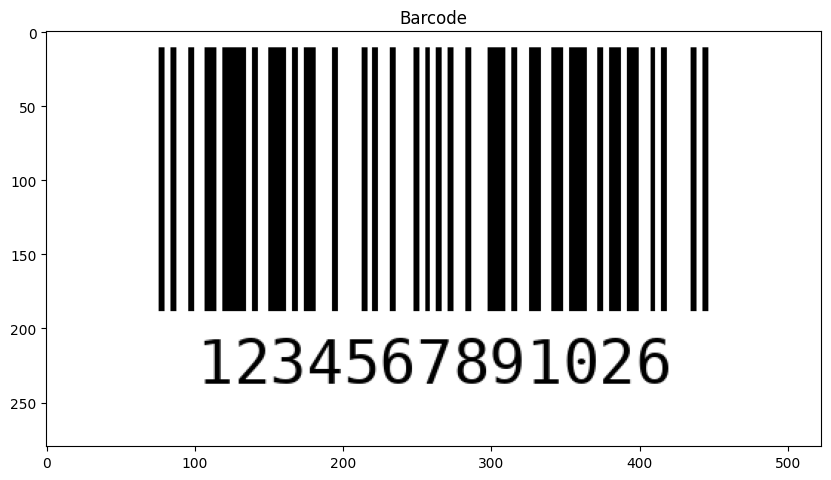

In [6]:
with open('barcode.png', 'wb') as f:
    EAN13('123456789102', writer=ImageWriter()).write(f)

barcode = cv2.imread("/content/barcode.png")
imshow("Barcode", barcode)

## **QR Code Generation**
Let's generate QR Codes using our qrcode package.

A QR code (abbreviated from Quick Response code) is a type of matrix barcode (or two-dimensional barcode) first designed in 1994 for the automotive industry in Japan. A barcode is a machine-readable optical label that contains information about the item to which it is attached. In practice, QR codes often contain data for a locator, identifier, or tracker that points to a website or application. A QR code uses four standardized encoding modes (numeric, alphanumeric, byte/binary, and kanji) to store data efficiently; extensions may also be used.

A QR code consists of black squares arranged in a square grid on a white background, which can be read by an imaging device such as a camera, and processed using Reed–Solomon error correction until the image can be appropriately interpreted. The required data is then extracted from patterns that are present in both horizontal and vertical components of the image.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/1/1d/QR_Code_Structure_Example_3.svg/800px-QR_Code_Structure_Example_3.svg.png)

**Configuartion for QR Codes**:

- version — Control the size of the QR Code. It accepts an integer from 1 to 40. Version 1 consists of 21 x 21 matrix.
- error_correction — Control the error correction used for the QR Code.
- box_size — Control the number of pixels of each boxes of the QR code.
- border — Control the boxes thickness of the border. The default is value is 4 which is also the minimum value according to the specification.

There are 4 constants available for error_correction. The higher errors can be corrected, the better it is.

- ERROR_CORRECT_L — About 7% or less errors can be corrected.
- ERROR_CORRECT_M — About 15% or less errors can be corrected. This is the default value.
- ERROR_CORRECT_Q — About 25% or less errors can be corrected.
- ERROR_CORRECT_H — About 30% or less errors can be corrected.

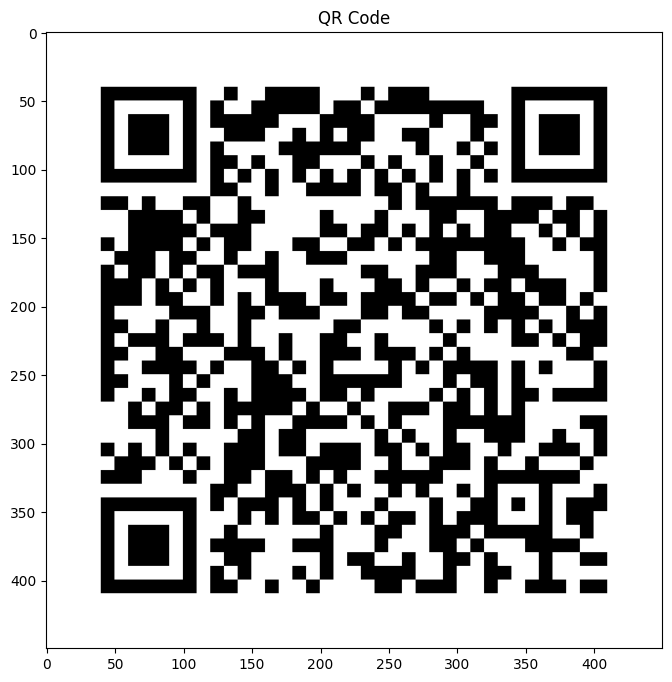

In [8]:
qr=qrcode.QRCode(version=1,error_correction=qrcode.constants.ERROR_CORRECT_L,box_size=10,border=4)
qr.add_data("https://github.com/jarif87/OpenCV/blob/main/27_Facial_Landmark_Detection_with_Dlib.ipynb")
qr.make(fit=True)
image=qr.make_image(fill_color="black",back_color="white")
image.save("qrcode.png")
qrcode=cv2.imread("/content/qrcode.png")
imshow("QR Code",qrcode)


# Decoding QR Codes

In [10]:
image=Image.open("/content/qrcode.png")
decoded_object=decode(image)
print(decoded_object[0].data.decode("ascii"))

https://github.com/jarif87/OpenCV/blob/main/27_Facial_Landmark_Detection_with_Dlib.ipynb


In [11]:
!wget https://i.stack.imgur.com/1DwED.jpg

--2025-02-28 12:36:57--  https://i.stack.imgur.com/1DwED.jpg
Resolving i.stack.imgur.com (i.stack.imgur.com)... 172.64.155.170, 104.18.32.86, 2606:4700:4400::ac40:9baa, ...
Connecting to i.stack.imgur.com (i.stack.imgur.com)|172.64.155.170|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://i.sstatic.net/1DwED.jpg [following]
--2025-02-28 12:36:57--  https://i.sstatic.net/1DwED.jpg
Resolving i.sstatic.net (i.sstatic.net)... 104.18.41.33, 172.64.146.223
Connecting to i.sstatic.net (i.sstatic.net)|104.18.41.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 439449 (429K) [image/jpeg]
Saving to: ‘1DwED.jpg’

1DwED.jpg           100%[===================>] 429.15K  --.-KB/s    in 0.05s   

2025-02-28 12:36:57 (8.28 MB/s) - ‘1DwED.jpg’ saved [439449/439449]



# Detecting QR Codes

In [12]:
image=cv2.imread("/content/1DwED.jpg")
detector=cv2.QRCodeDetector()
data,bbox,straight_qrcode=detector.detectAndDecode(image)
print(data)

http://ruthenus.pl


[Point(x=558, y=938), Point(x=588, y=1288), Point(x=916, y=1275), Point(x=875, y=896)]
QR Code Revealed : http://ruthenus.pl (QRCODE)


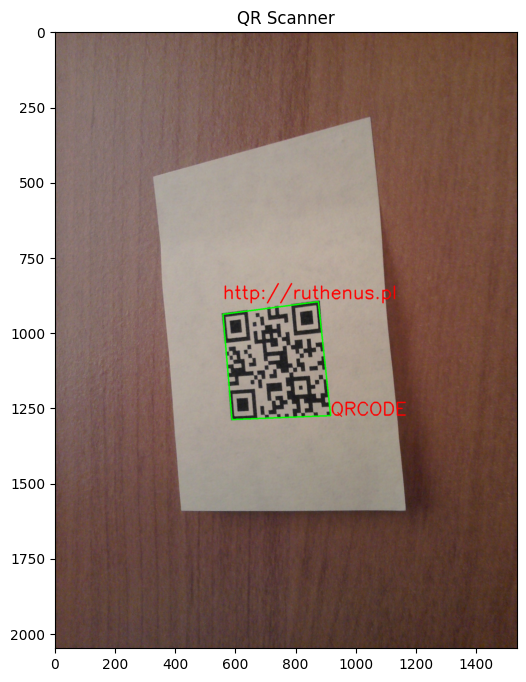

In [18]:
image=cv2.imread("/content/1DwED.jpg")


codes=decode(image)

for i in codes:
  (x,y,w,h)=i.rect
  print(i.polygon)
  pt1,pt2,pt3,pt4=i.polygon

  # draw bounding box over detected qr code
  pts=np.array([[pt1.x,pt1.y],[pt2.x,pt2.y],[pt3.x,pt3.y],[pt4.x,pt4.y]],np.int32)
  pts=pts.reshape((-1,1,2))
  cv2.polylines(image,[pts],True,(0,255,0),3)

  # extract the string info data and type from our object

  barcode_text=i.data.decode()
  barcode_type=i.type

  text="{} ({})".format(barcode_text,barcode_type)
  cv2.putText(image,barcode_text,(x,y-10),cv2.FONT_HERSHEY_SIMPLEX,2,(0,0,255),3)
  cv2.putText(image,barcode_type,(x+w,y+h-15),cv2.FONT_HERSHEY_SIMPLEX,2,(0,0,255),3)
  print(f"QR Code Revealed : {text}")

imshow("QR Scanner",image)



Barcode revealed: 9780863815805
Barcode revealed: 9780863815805


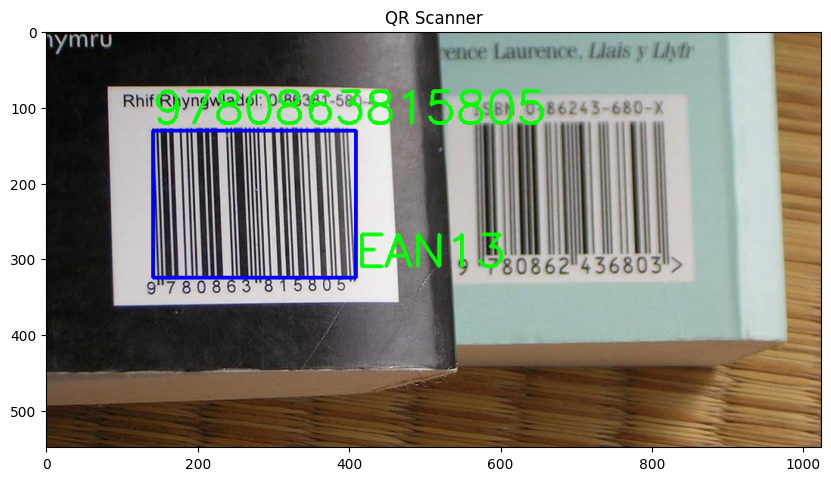

In [21]:

image = cv2.imread("/content/1024px-ISBN.jpg")

# Detect and decode the qrcode
barcodes = decode(image)

# loop over the detected barcodes
for bc in barcodes:
  # Get the rect coordiantes for our text placement
  (x, y, w, h) = bc.rect
  cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 3)

  # extract the string info data and the type from our object
  barcode_text = bc.data.decode()
  barcode_type = bc.type

  # show our
  text = "{} ({})".format(barcode_text, barcode_type)
  cv2.putText(image, barcode_text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 3)
  cv2.putText(image, barcode_type, (x+w, y+h - 15), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 3)
  print("Barcode revealed: {}".format(barcode_text))
  print("Barcode revealed: {}".format(barcode_text))

# display our output
imshow("QR Scanner", image)